In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

LAB 1 : REGRESSION

ข้อมูลใน train.csv
          ID   Class
0    377.jpg  MIDDLE
1  17814.jpg   YOUNG
2  21283.jpg  MIDDLE
3  16496.jpg   YOUNG
4   4487.jpg  MIDDLE

Column:
['ID', 'Class']

จำนวนข้อมูลทั้งหมด: 19906

จำนวนข้อมูลแต่ละ Class
Class
MIDDLE    10804
YOUNG      6706
OLD        2396
Name: count, dtype: int64

กำลังอ่านรูปภาพ...
อ่านรูปสำเร็จ: 32 รูป
Feature shape: (32, 1024)
Target shape: (32,)

Training: 25
Testing : 7


LAB 1.1 : SIMPLE LINEAR REGRESSION
Intercept = 0.20065331
Coefficient = 1.5190411
MSE = 0.5084506273269653
R2 = -0.038086771965026855


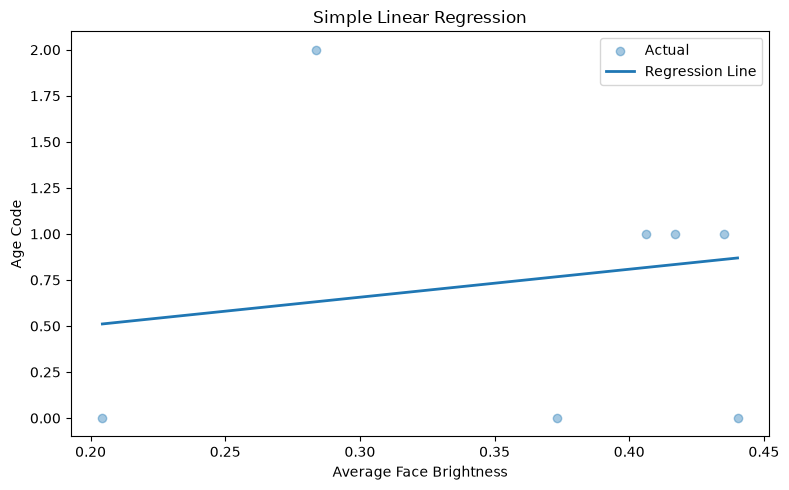



LAB 1.2 : MULTIPLE LINEAR REGRESSION
จำนวน Features = 10
Intercept = 0.76
MSE = 0.3401775360107422
R2 = 0.3054708242416382
Explained Variance = 0.8796976


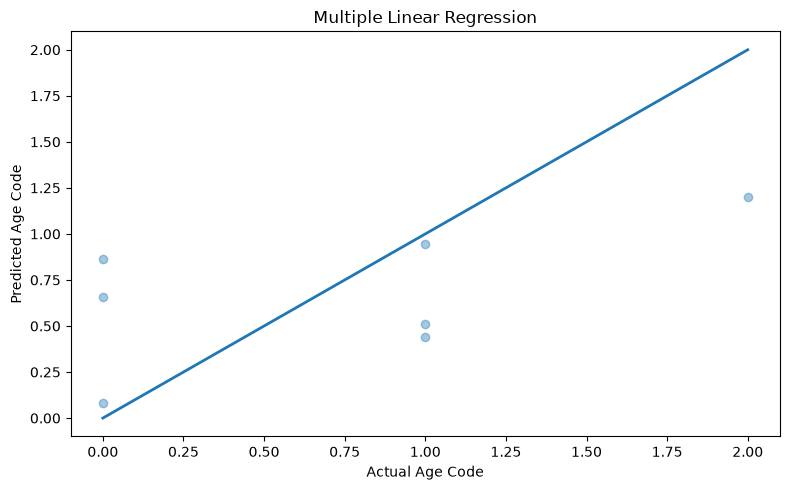



LAB 1.3 : AGE PREDICTION
Accuracy = 0.42857142857142855
Accuracy (%) = 42.857142857142854

ตัวอย่างผลการทำนาย
Actual Predicted  Predicted_Value
 YOUNG    MIDDLE            0.862
MIDDLE    MIDDLE            0.508
 YOUNG     YOUNG            0.080
   OLD    MIDDLE            1.201
MIDDLE     YOUNG            0.441
 YOUNG    MIDDLE            0.660
MIDDLE    MIDDLE            0.947


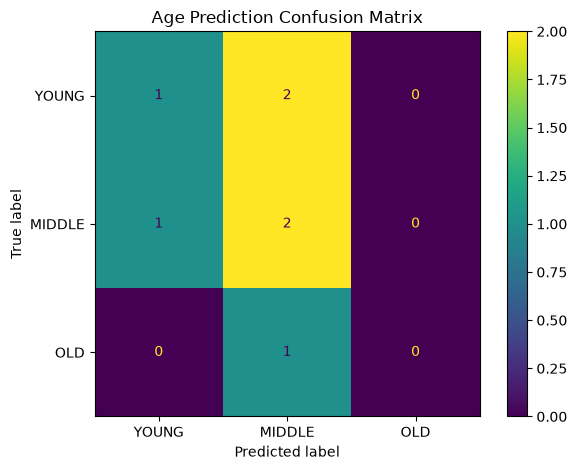



SUMMARY : LAB 1
                     Model      MSE        R2  Accuracy
  Simple Linear Regression 0.508451 -0.038087       NaN
Multiple Linear Regression 0.340178  0.305471       NaN
            Age Prediction 0.340178  0.305471  0.428571

บันทึกผลเรียบร้อย
LAB1_Summary.csv
LAB1_Age_Prediction.csv

จบ LAB 1


In [47]:
# ============================================================
# LAB 1 : Regression & Classification
# LAB 1 - Regression
# Dataset: Faces
# ============================================================

# ============================================================
# 1) กำหนดตำแหน่ง Dataset
# ============================================================
# โฟลเดอร์หลักตามที่ผู้ใช้แจ้ง
BASE_DIR = r"C:\Users\Asus\OneDrive\Desktop\ML\ML-03-Regression & Classification 1"

# ไฟล์ train.csv
CSV_FILE = os.path.join(BASE_DIR, "train.csv")

# โฟลเดอร์รูป Train
IMAGE_DIR = os.path.join(BASE_DIR, "Train")


# ============================================================
# 2) ตรวจสอบไฟล์
# ============================================================
print("=" * 60)
print("LAB 1 : REGRESSION")
print("=" * 60)

if not os.path.exists(CSV_FILE):
    print("ไม่พบ train.csv ที่:")
    print(CSV_FILE)
    print("\nถ้า train.csv อยู่ในโฟลเดอร์ย่อย ให้แก้ CSV_FILE ให้ตรงตำแหน่ง")
    raise FileNotFoundError(CSV_FILE)

if not os.path.exists(IMAGE_DIR):
    print("ไม่พบโฟลเดอร์ Train ที่:")
    print(IMAGE_DIR)
    print("\nตรวจสอบชื่อโฟลเดอร์ว่า Train หรือ train")
    raise FileNotFoundError(IMAGE_DIR)


# ============================================================
# 3) อ่าน train.csv
# ============================================================
df = pd.read_csv(CSV_FILE)

print("\nข้อมูลใน train.csv")
print(df.head())

print("\nColumn:")
print(df.columns.tolist())

print("\nจำนวนข้อมูลทั้งหมด:", len(df))


# ============================================================
# 4) ตรวจสอบชื่อ Column
# ============================================================
# Dataset นี้ควรมี Column: ID และ Class
if "ID" not in df.columns:
    raise ValueError("ไม่พบ Column 'ID' ใน train.csv")

if "Class" not in df.columns:
    raise ValueError("ไม่พบ Column 'Class' ใน train.csv")


# ============================================================
# 5) แสดงจำนวนข้อมูลแต่ละกลุ่มอายุ
# ============================================================
print("\nจำนวนข้อมูลแต่ละ Class")
print(df["Class"].value_counts())


# ============================================================
# 6) แปลง Class เป็นตัวเลข
# ============================================================
# YOUNG  = 0
# MIDDLE = 1
# OLD    = 2

class_to_code = {
    "YOUNG": 0,
    "MIDDLE": 1,
    "OLD": 2
}

code_to_class = {
    0: "YOUNG",
    1: "MIDDLE",
    2: "OLD"
}

df["AgeCode"] = df["Class"].str.upper().map(class_to_code)

# ตัดข้อมูลที่ไม่มี Class
df = df.dropna(subset=["AgeCode"]).copy()
df["AgeCode"] = df["AgeCode"].astype(int)


# ============================================================
# 7) เตรียมรูปภาพเป็น Features
# ============================================================
IMAGE_SIZE = (32, 32)

def load_image(image_name):
    """
    อ่านรูปภาพจากโฟลเดอร์ Train
    และ resize เป็น 32x32 grayscale
    """
    image_path = os.path.join(IMAGE_DIR, str(image_name))

    # ถ้า ID ไม่มี .jpg ให้ลองเติม .jpg
    if not os.path.exists(image_path):
        image_path = os.path.join(IMAGE_DIR, str(image_name) + ".jpg")

    if not os.path.exists(image_path):
        return None

    try:
        image = Image.open(image_path).convert("L")
        image = image.resize(IMAGE_SIZE)

        # Normalize 0-255 -> 0-1
        image = np.asarray(image, dtype=np.float32) / 255.0

        # เปลี่ยน 32x32 เป็น 1 มิติ
        return image.flatten()

    except Exception:
        return None


X_list = []
y_list = []
id_list = []

print("\nกำลังอ่านรูปภาพ...")

for _, row in df.iterrows():

    features = load_image(row["ID"])

    if features is not None:
        X_list.append(features)
        y_list.append(row["AgeCode"])
        id_list.append(row["ID"])


X = np.array(X_list, dtype=np.float32)
y = np.array(y_list, dtype=np.float32)

print("อ่านรูปสำเร็จ:", len(X), "รูป")
print("Feature shape:", X.shape)
print("Target shape:", y.shape)


# ============================================================
# 8) Train / Test Split
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining:", len(X_train))
print("Testing :", len(X_test))


# ============================================================
# LAB 1.1
# Simple Linear Regression
# ============================================================
# ใช้ Feature เพียง 1 ตัว
# คือค่าเฉลี่ยความสว่างของใบหน้า

print("\n")
print("=" * 60)
print("LAB 1.1 : SIMPLE LINEAR REGRESSION")
print("=" * 60)

X_train_simple = X_train.mean(axis=1).reshape(-1, 1)
X_test_simple = X_test.mean(axis=1).reshape(-1, 1)

simple_model = LinearRegression()

simple_model.fit(
    X_train_simple,
    y_train
)

simple_prediction = simple_model.predict(X_test_simple)

simple_mse = mean_squared_error(
    y_test,
    simple_prediction
)

simple_r2 = r2_score(
    y_test,
    simple_prediction
)

print("Intercept =", simple_model.intercept_)
print("Coefficient =", simple_model.coef_[0])
print("MSE =", simple_mse)
print("R2 =", simple_r2)


# กราฟ Simple Linear Regression
plt.figure(figsize=(8, 5))

plt.scatter(
    X_test_simple,
    y_test,
    alpha=0.4,
    label="Actual"
)

sort_index = np.argsort(X_test_simple[:, 0])

plt.plot(
    X_test_simple[sort_index],
    simple_prediction[sort_index],
    linewidth=2,
    label="Regression Line"
)

plt.xlabel("Average Face Brightness")
plt.ylabel("Age Code")
plt.title("Simple Linear Regression")
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# LAB 1.2
# Multiple Linear Regression
# ============================================================
# ใช้ PCA ลดจำนวน Pixel
# จาก 1024 features เหลือ 10 features

print("\n")
print("=" * 60)
print("LAB 1.2 : MULTIPLE LINEAR REGRESSION")
print("=" * 60)

pca = PCA(
    n_components=10,
    random_state=42
)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

multiple_model = LinearRegression()

multiple_model.fit(
    X_train_pca,
    y_train
)

multiple_prediction = multiple_model.predict(
    X_test_pca
)

multiple_mse = mean_squared_error(
    y_test,
    multiple_prediction
)

multiple_r2 = r2_score(
    y_test,
    multiple_prediction
)

print("จำนวน Features =", X_train_pca.shape[1])
print("Intercept =", multiple_model.intercept_)
print("MSE =", multiple_mse)
print("R2 =", multiple_r2)

print(
    "Explained Variance =",
    pca.explained_variance_ratio_.sum()
)


# กราฟ Actual vs Predicted
plt.figure(figsize=(8, 5))

plt.scatter(
    y_test,
    multiple_prediction,
    alpha=0.4
)

plt.plot(
    [0, 2],
    [0, 2],
    linewidth=2
)

plt.xlabel("Actual Age Code")
plt.ylabel("Predicted Age Code")
plt.title("Multiple Linear Regression")
plt.tight_layout()
plt.show()


# ============================================================
# LAB 1.3
# Age Prediction
# ============================================================
print("\n")
print("=" * 60)
print("LAB 1.3 : AGE PREDICTION")
print("=" * 60)

# ปัดค่าที่ Regression ทำนาย
# 0 = YOUNG
# 1 = MIDDLE
# 2 = OLD

prediction_code = np.clip(
    np.rint(multiple_prediction),
    0,
    2
).astype(int)

actual_code = y_test.astype(int)

prediction_class = [
    code_to_class[x]
    for x in prediction_code
]

actual_class = [
    code_to_class[x]
    for x in actual_code
]

accuracy = accuracy_score(
    actual_class,
    prediction_class
)

print("Accuracy =", accuracy)
print("Accuracy (%) =", accuracy * 100)


# ตารางผลการทำนาย
result = pd.DataFrame({
    "Actual": actual_class,
    "Predicted": prediction_class,
    "Predicted_Value": multiple_prediction.round(3)
})

print("\nตัวอย่างผลการทำนาย")
print(result.head(20).to_string(index=False))


# ============================================================
# 9) Confusion Matrix แบบง่ายสำหรับ Age Prediction
# ============================================================
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(
    actual_class,
    prediction_class,
    labels=["YOUNG", "MIDDLE", "OLD"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["YOUNG", "MIDDLE", "OLD"]
)

disp.plot()

plt.title("Age Prediction Confusion Matrix")
plt.tight_layout()
plt.show()


# ============================================================
# 10) สรุปผล LAB 1
# ============================================================
summary = pd.DataFrame({
    "Model": [
        "Simple Linear Regression",
        "Multiple Linear Regression",
        "Age Prediction"
    ],

    "MSE": [
        simple_mse,
        multiple_mse,
        multiple_mse
    ],

    "R2": [
        simple_r2,
        multiple_r2,
        multiple_r2
    ],

    "Accuracy": [
        np.nan,
        np.nan,
        accuracy
    ]
})

print("\n")
print("=" * 60)
print("SUMMARY : LAB 1")
print("=" * 60)

print(summary.to_string(index=False))


# ============================================================
# 11) Save Result
# ============================================================
summary.to_csv(
    os.path.join(BASE_DIR, "LAB1_Summary.csv"),
    index=False
)

result.to_csv(
    os.path.join(BASE_DIR, "LAB1_Age_Prediction.csv"),
    index=False
)

print("\nบันทึกผลเรียบร้อย")
print("LAB1_Summary.csv")
print("LAB1_Age_Prediction.csv")
print("\nจบ LAB 1")


Dataset:
          ID   Class  AgeCode
0    377.jpg  MIDDLE        1
1  17814.jpg   YOUNG        0
2  21283.jpg  MIDDLE        1
3  16496.jpg   YOUNG        0
4   4487.jpg  MIDDLE        1

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 19906 entries, 0 to 19905
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   ID       19906 non-null  str  
 1   Class    19906 non-null  str  
 2   AgeCode  19906 non-null  int64
dtypes: int64(1), str(2)
memory usage: 466.7 KB
None

Class Distribution:
Class
MIDDLE    10804
YOUNG      6706
OLD        2396
Name: count, dtype: int64

Class Encoding:
0 = MIDDLE
1 = OLD
2 = YOUNG

Training Data: (15924, 1)
Testing Data : (3982, 1)

LOGISTIC REGRESSION
Accuracy: 0.542692114515319

Classification Report:
              precision    recall  f1-score   support

      MIDDLE       0.54      1.00      0.70      2161
         OLD       0.00      0.00      0.00       479
       YOUNG       0.00 

c:\Users\Asus\anaconda3\envs\Phum\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Asus\anaconda3\envs\Phum\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Asus\anaconda3\envs\Phum\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


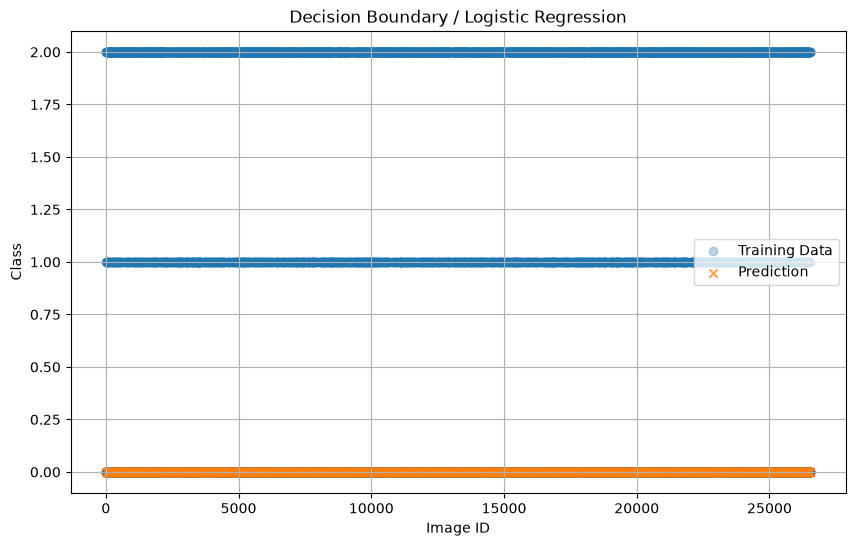


Confusion Matrix:
[[2161    0    0]
 [ 479    0    0]
 [1342    0    0]]


<Figure size 700x600 with 0 Axes>

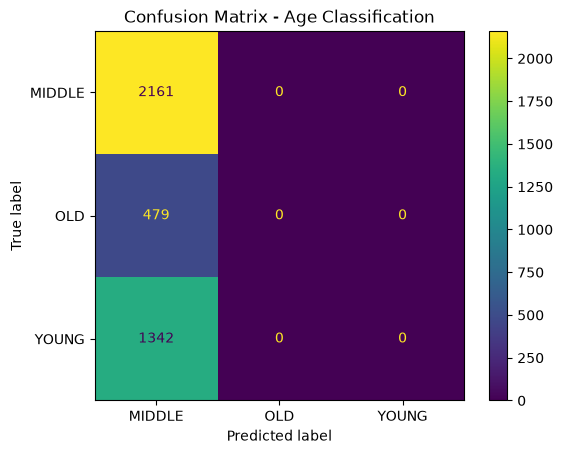


TEST PREDICTION
Image ID: 10000
Predicted Class: MIDDLE


In [48]:
# ============================================
# LAB 2: CLASSIFICATION
# Age Classification
# ============================================

# ============================================
# 1. Preparing Classification Data
# ============================================

# อ่าน Dataset


print("Dataset:")
print(df.head())

print("\nDataset Information:")
print(df.info())

print("\nClass Distribution:")
print(df["Class"].value_counts())

# --------------------------------------------
# สร้าง Feature จาก ID
# --------------------------------------------

# ดึงตัวเลขออกจากชื่อไฟล์
df["Image_ID"] = df["ID"].str.extract(r"(\d+)").astype(int)

# Feature ที่ใช้ในการทดลอง
X = df[["Image_ID"]]
y = df["Class"]

# แปลง Class เป็นตัวเลข
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("\nClass Encoding:")
for i, name in enumerate(label_encoder.classes_):
    print(i, "=", name)


# ============================================
# 2. Split Training / Testing Data
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("\nTraining Data:", X_train.shape)
print("Testing Data :", X_test.shape)


# ============================================
# Standardization
# ============================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# ============================================
# 3. Logistic Regression
# ============================================

model = LogisticRegression(
    max_iter=1000
)

model.fit(X_train_scaled, y_train)

# Prediction
y_pred = model.predict(X_test_scaled)

print("\n===================================")
print("LOGISTIC REGRESSION")
print("===================================")

print("Accuracy:",
      accuracy_score(y_test, y_pred))

# ============================================
# Classification Report
# ============================================

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    )
)
# ============================================
# 4. Decision Boundary Visualization
# ============================================

plt.figure(figsize=(10, 6))

# Plot training data
plt.scatter(
    X_train["Image_ID"],
    y_train,
    alpha=0.3,
    label="Training Data"
)

# Plot testing prediction
plt.scatter(
    X_test["Image_ID"],
    y_pred,
    alpha=0.7,
    marker="x",
    label="Prediction"
)

plt.xlabel("Image ID")
plt.ylabel("Class")
plt.title("Decision Boundary / Logistic Regression")
plt.legend()
plt.grid(True)

plt.show()


# ============================================
# 5. Confusion Matrix
# ============================================

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot()

plt.title("Confusion Matrix - Age Classification")
plt.show()


# ============================================
# 6. Test Prediction
# ============================================

print("\n===================================")
print("TEST PREDICTION")
print("===================================")

# ทดลองทำนาย Image ID
test_id = 10000

test_data = pd.DataFrame({
    "Image_ID": [test_id]
})

test_scaled = scaler.transform(test_data)

prediction = model.predict(test_scaled)

predicted_class = label_encoder.inverse_transform(prediction)

print("Image ID:", test_id)
print("Predicted Class:", predicted_class[0])

DATASET
          ID   Class  AgeCode  Image_ID
0    377.jpg  MIDDLE        1       377
1  17814.jpg   YOUNG        0     17814
2  21283.jpg  MIDDLE        1     21283
3  16496.jpg   YOUNG        0     16496
4   4487.jpg  MIDDLE        1      4487

Shape: (19906, 4)

Columns: ['ID', 'Class', 'AgeCode', 'Image_ID']

Class Encoding:
0 = MIDDLE
1 = OLD
2 = YOUNG

Class Distribution:
Class
MIDDLE    10804
YOUNG      6706
OLD        2396
Name: count, dtype: int64

SIMPLE LINEAR REGRESSION
R2 Score: 0.00012443526164096497
MAE: 0.8620883919916457
MSE: 0.8373020585083535
RMSE: 0.9150421075056346

MULTIPLE LINEAR REGRESSION
R2 Score: 0.00011187790804456643
MAE: 0.8620675618602733
MSE: 0.8373125741148814
RMSE: 0.9150478534562448

SIMPLE vs MULTIPLE REGRESSION
Simple Regression R2   : 0.00012443526164096497
Multiple Regression R2 : 0.00011187790804456643

Simple Linear Regression performs better.

TRAINING vs TESTING

Simple Linear Regression
Training R2: 5.794386085167247e-06
Testing R2 : 0.0001

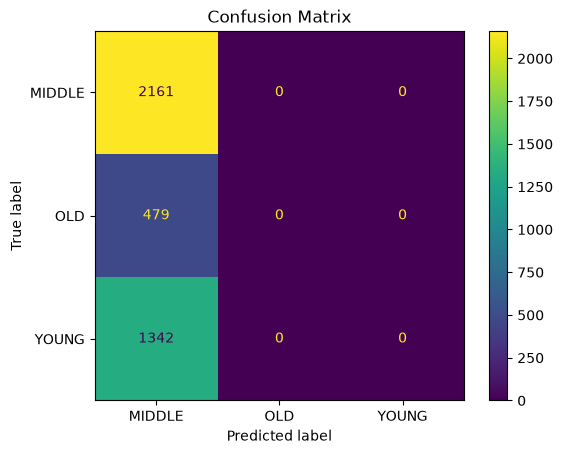

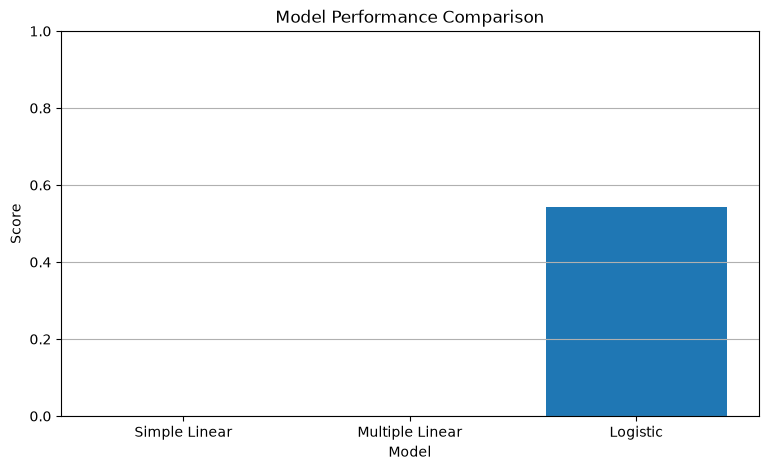

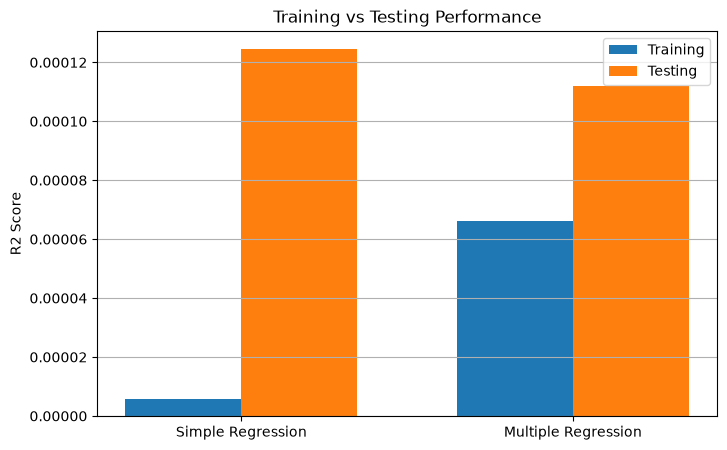


LAB 3 COMPLETED


In [49]:
# ============================================
# LAB 3: MODEL COMPARISON
# ============================================

print("===================================")
print("DATASET")
print("===================================")

print(df.head())
print("\nShape:", df.shape)
print("\nColumns:", df.columns.tolist())


# ============================================
# 2. Preparing Data
# ============================================

# แปลง ID เช่น 377.jpg -> 377
df["Image_ID"] = (
    df["ID"]
    .str.extract(r"(\d+)")
    .astype(int)
)

# Encode Class
encoder = LabelEncoder()

df["Class_Code"] = encoder.fit_transform(df["Class"])

print("\nClass Encoding:")
for i, name in enumerate(encoder.classes_):
    print(i, "=", name)

print("\nClass Distribution:")
print(df["Class"].value_counts())


# ============================================
# 3. Simple Linear Regression
# ============================================

X = df[["Image_ID"]]
y = df["Class_Code"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

simple_model = LinearRegression()

simple_model.fit(X_train, y_train)

y_pred_simple = simple_model.predict(X_test)

print("\n===================================")
print("SIMPLE LINEAR REGRESSION")
print("===================================")

print("R2 Score:",
      r2_score(y_test, y_pred_simple))

print("MAE:",
      mean_absolute_error(y_test, y_pred_simple))

print("MSE:",
      mean_squared_error(y_test, y_pred_simple))

print("RMSE:",
      np.sqrt(mean_squared_error(y_test, y_pred_simple)))


# ============================================
# 4. Multiple Linear Regression
# ============================================

# สร้าง Feature เพิ่มเติม
df["Image_ID_Squared"] = df["Image_ID"] ** 2
df["Image_ID_Sqrt"] = np.sqrt(df["Image_ID"])

X_multiple = df[
    [
        "Image_ID",
        "Image_ID_Squared",
        "Image_ID_Sqrt"
    ]
]

y_multiple = df["Class_Code"]

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multiple,
    y_multiple,
    test_size=0.20,
    random_state=42,
    stratify=y_multiple
)

multiple_model = LinearRegression()

multiple_model.fit(X_train_m, y_train_m)

y_pred_multiple = multiple_model.predict(X_test_m)

print("\n===================================")
print("MULTIPLE LINEAR REGRESSION")
print("===================================")

print("R2 Score:",
      r2_score(y_test_m, y_pred_multiple))

print("MAE:",
      mean_absolute_error(y_test_m, y_pred_multiple))

print("MSE:",
      mean_squared_error(y_test_m, y_pred_multiple))

print("RMSE:",
      np.sqrt(mean_squared_error(y_test_m, y_pred_multiple)))


# ============================================
# 5. Compare Simple vs Multiple Regression
# ============================================

simple_r2 = r2_score(y_test, y_pred_simple)
multiple_r2 = r2_score(y_test_m, y_pred_multiple)

print("\n===================================")
print("SIMPLE vs MULTIPLE REGRESSION")
print("===================================")

print("Simple Regression R2   :", simple_r2)
print("Multiple Regression R2 :", multiple_r2)

if multiple_r2 > simple_r2:
    print("\nMultiple Linear Regression performs better.")
elif simple_r2 > multiple_r2:
    print("\nSimple Linear Regression performs better.")
else:
    print("\nBoth models have the same performance.")


# ============================================
# 6. Training vs Testing Performance
# ============================================

# Simple Regression
train_pred_simple = simple_model.predict(X_train)

train_r2_simple = r2_score(
    y_train,
    train_pred_simple
)

test_r2_simple = r2_score(
    y_test,
    y_pred_simple
)


# Multiple Regression
train_pred_multiple = multiple_model.predict(X_train_m)

train_r2_multiple = r2_score(
    y_train_m,
    train_pred_multiple
)

test_r2_multiple = r2_score(
    y_test_m,
    y_pred_multiple
)


print("\n===================================")
print("TRAINING vs TESTING")
print("===================================")

print("\nSimple Linear Regression")
print("Training R2:", train_r2_simple)
print("Testing R2 :", test_r2_simple)

print("\nMultiple Linear Regression")
print("Training R2:", train_r2_multiple)
print("Testing R2 :", test_r2_multiple)


# ============================================
# 7. Logistic Regression Classification
# ============================================

X_class = df[["Image_ID"]]
y_class = df["Class_Code"]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class,
    y_class,
    test_size=0.20,
    random_state=42,
    stratify=y_class
)

# Standardization
scaler = StandardScaler()

X_train_c_scaled = scaler.fit_transform(X_train_c)
X_test_c_scaled = scaler.transform(X_test_c)

# Logistic Regression
logistic_model = LogisticRegression(
    max_iter=1000
)

logistic_model.fit(
    X_train_c_scaled,
    y_train_c
)

y_pred_class = logistic_model.predict(
    X_test_c_scaled
)


# ============================================
# 8. Regression vs Classification
# ============================================

print("\n===================================")
print("REGRESSION vs CLASSIFICATION")
print("===================================")

print("\nRegression:")
print("R2 Score:", test_r2_simple)
print("MAE:", mean_absolute_error(y_test, y_pred_simple))
print("RMSE:",
      np.sqrt(mean_squared_error(
          y_test,
          y_pred_simple
      )))

print("\nClassification:")
print("Accuracy:",
      accuracy_score(
          y_test_c,
          y_pred_class
      ))

print("Precision:",
      precision_score(
          y_test_c,
          y_pred_class,
          average="weighted",
          zero_division=0
      ))

print("Recall:",
      recall_score(
          y_test_c,
          y_pred_class,
          average="weighted",
          zero_division=0
      ))

print("F1 Score:",
      f1_score(
          y_test_c,
          y_pred_class,
          average="weighted",
          zero_division=0
      ))


# ============================================
# 9. Model Performance Metrics
# ============================================

accuracy = accuracy_score(
    y_test_c,
    y_pred_class
)

precision = precision_score(
    y_test_c,
    y_pred_class,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_test_c,
    y_pred_class,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_test_c,
    y_pred_class,
    average="weighted",
    zero_division=0
)


print("\n===================================")
print("MODEL PERFORMANCE METRICS")
print("===================================")

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")


# ============================================
# 10. Classification Report
# ============================================

print("\n===================================")
print("CLASSIFICATION REPORT")
print("===================================")

print(
    classification_report(
        y_test_c,
        y_pred_class,
        target_names=encoder.classes_,
        zero_division=0
    )
)


# ============================================
# 11. Confusion Matrix
# ============================================

cm = confusion_matrix(
    y_test_c,
    y_pred_class
)

print("\n===================================")
print("CONFUSION MATRIX")
print("===================================")

print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=encoder.classes_
)

disp.plot()

plt.title("Confusion Matrix")
plt.show()


# ============================================
# 12. Model Comparison Graph
# ============================================

models = [
    "Simple Linear",
    "Multiple Linear",
    "Logistic"
]

scores = [
    test_r2_simple,
    test_r2_multiple,
    accuracy
]

plt.figure(figsize=(9, 5))

plt.bar(models, scores)

plt.xlabel("Model")
plt.ylabel("Score")
plt.title("Model Performance Comparison")

plt.ylim(0, 1)

plt.grid(axis="y")

plt.show()


# ============================================
# 13. Training vs Testing Graph
# ============================================

train_scores = [
    train_r2_simple,
    train_r2_multiple
]

test_scores = [
    test_r2_simple,
    test_r2_multiple
]

x = np.arange(2)
width = 0.35

plt.figure(figsize=(8, 5))

plt.bar(
    x - width / 2,
    train_scores,
    width,
    label="Training"
)

plt.bar(
    x + width / 2,
    test_scores,
    width,
    label="Testing"
)

plt.xticks(
    x,
    ["Simple Regression", "Multiple Regression"]
)

plt.ylabel("R2 Score")

plt.title("Training vs Testing Performance")

plt.legend()

plt.grid(axis="y")

plt.show()


# ============================================
# END LAB 3
# ============================================

print("\n===================================")
print("LAB 3 COMPLETED")
print("===================================")